In [108]:
#-------------------------------------------------------------------------------------------------------------------
# Import libraries
#-------------------------------------------------------------------------------------------------------------------

In [290]:
#Import libraries 
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
!pip install arch 
from arch import arch_model
from statsmodels.graphics.tsaplots import plot_acf
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import xgboost as xgb
from scipy import stats
import statsmodels.api as sm

In [291]:
#-------------------------------------------------------------------------------------------------------------------
# Load and process data
#-------------------------------------------------------------------------------------------------------------------

In [292]:
#Import datasets
FTSE100 = pd.read_csv("/Users/weronikab/Documents/Dissertation/Dissertation Data/FTSE100 Bloomberg Price Data 2003-2025.csv")
GDP = pd.read_csv("/Users/weronikab/Documents/Dissertation/Dissertation Data/Bloomberg GDP growth data 2003-2025.csv")
Unemp = pd.read_csv("/Users/weronikab/Documents/Dissertation/Dissertation Data/Bloomberg UK unemployment rate data 2002-2025.csv")
Social = pd.read_csv("/Users/weronikab/Documents/Dissertation/Dissertation Data/Bloomberg FTSE100 Social media volume data 2016-2025.csv")

In [293]:
#Convert arguments into structure data
FTSE100["Date"] = pd.to_datetime(FTSE100["Date"])
GDP["Date"] = pd.to_datetime(GDP["Date"])
Unemp["Date"] = pd.to_datetime(Unemp["Date"])
Social["Date"] = pd.to_datetime(Social["Date"])

In [294]:
#Rename variables
GDP = GDP.rename(columns={"Latest": "GDP_growth"})
Unemp = Unemp.rename(columns={"Latest": "Unemp_rate"})
Social = Social.rename(columns={"ftse100 - Story Count: Social Media": "Social_Count"})

In [295]:
#Compute percentage change for social media data
Social["post_growth"] = Social["Social_Count"].pct_change()*100

In [296]:
#Lag social media percentage by one month
Social["social_growth_lag1"] = (
    Social["post_growth"].shift(1)
)

In [297]:
#Create merge variables
FTSE100["Month"] = FTSE100["Date"].dt.to_period("M")
Social["Month"] = Social["Date"].dt.to_period("M")

In [298]:
#Sort values by date
FTSE100 = FTSE100.sort_values("Date")
GDP = GDP.sort_values("Date")
Unemp = Unemp.sort_values("Date")
Social = Social.sort_values("Date")

In [299]:
#-------------------------------------------------------------------------------------------------------------------
# Merge datasets
#-------------------------------------------------------------------------------------------------------------------

In [300]:
#Merge social media variable and assign data from previous month
FTSE100 = FTSE100.merge(
    Social[["Month", "social_growth_lag1"]],
    on="Month",
    how="left"
)

In [301]:
#Merge other datasets
FTSE100 = pd.merge_asof(
    FTSE100,
    GDP[["Date", "GDP_growth"]],
    on="Date",
    direction="backward"
)

In [302]:
FTSE100 = pd.merge_asof(
    FTSE100,
    Unemp[["Date", "Unemp_rate"]],
    on="Date",
    direction="backward"
)

In [303]:
#-------------------------------------------------------------------------------------------------------------------
# Calculate time series variables
#-------------------------------------------------------------------------------------------------------------------

In [304]:
#Set date as index
FTSE100 = FTSE100.set_index("Date")

In [305]:
#Sort index
FTSE100 = FTSE100.sort_index()

In [306]:
#Find log returns
FTSE100["log_return"] = np.log(FTSE100["Price"] / FTSE100["Price"].shift(1))

In [307]:
#Compute returns 
FTSE100["returns"] = FTSE100["log_return"]*100

In [308]:
#Compute historical volatility 
FTSE100["historical_vol"] = (
    FTSE100["log_return"]
    .rolling(20)
    .std()
    * np.sqrt(252)
)

In [309]:
#-------------------------------------------------------------------------------------------------------------------
# Remove missing values
#-------------------------------------------------------------------------------------------------------------------

In [310]:
FTSE100 = FTSE100.dropna(axis=1, how="all")

In [311]:
#-------------------------------------------------------------------------------------------------------------------
# Compute target
#-------------------------------------------------------------------------------------------------------------------

In [312]:
#compute target of 20-day forward realised volatility
FTSE100["target"] = (
    FTSE100["log_return"]
    .shift(-1)
    .rolling(20)
    .std()
    .shift(-(20 - 1))
    * np.sqrt(252)
)

In [313]:
#-------------------------------------------------------------------------------------------------------------------
# Compute XGBoost variables
#-------------------------------------------------------------------------------------------------------------------

In [314]:
#Compute lagged returns and target
FTSE100["return_lag1"] = FTSE100["returns"].shift(1)
FTSE100["return_lag2"] = FTSE100["returns"].shift(2)
FTSE100["return_lag5"] = FTSE100["returns"].shift(5)
FTSE100["return_lag10"] = FTSE100["returns"].shift(10)

FTSE100["vol_lag1"] = FTSE100["historical_vol"].shift(1)
FTSE100["vol_lag5"] = FTSE100["historical_vol"].shift(5)
FTSE100["vol_lag10"] = FTSE100["historical_vol"].shift(10)

In [315]:
#Compute lagged volume
FTSE100["volume_lag1"] = FTSE100["Volume"].shift(1)
FTSE100["volume_lag5"] = FTSE100["Volume"].shift(5)
FTSE100["volume_lag10"] = FTSE100["Volume"].shift(10)

In [316]:
#Compose feature set's
features1 = [
    "return_lag1",
    "return_lag2",
    "return_lag5",
    "return_lag10"
]

In [317]:
features2 = [
    "return_lag1",
    "return_lag2",
    "return_lag5",
    "return_lag10",
    "vol_lag1",
    "vol_lag5",
    "vol_lag10"
]

In [318]:
features3 = [
    "return_lag1",
    "return_lag2",
    "return_lag5",
    "return_lag10",
    "vol_lag1",
    "vol_lag5",
    "vol_lag10",
    "volume_lag1",
    "volume_lag5",
    "volume_lag10"
]

In [319]:
features4 = [
    "return_lag1",
    "return_lag2",
    "return_lag5",
    "return_lag10",
    "vol_lag1",
    "vol_lag5",
    "vol_lag10",
    "volume_lag1",
    "volume_lag5",
    "volume_lag10",
    "GDP_growth",
    "Unemp_rate"
]

In [320]:
features5 = [
    "return_lag1",
    "return_lag2",
    "return_lag5",
    "return_lag10",
    "vol_lag1",
    "vol_lag5",
    "vol_lag10",
    "volume_lag1",
    "volume_lag5",
    "volume_lag10",
    "GDP_growth",
    "Unemp_rate",
    "social_growth_lag1"
]

In [321]:
#Create feature set for XGBoost
features_set = {"XGBoost 1 - Returns": features1,
    "XGBoost 2 - Returns + Volatility": features2,
    "XGBoost 3 - + Volume": features3,
    "XGBoost 4 - + Macro": features4,
    "XGBoost 5 - + Social Media": features5
}

In [322]:
#Create common data set
common_df = FTSE100.dropna(
    subset=features5 + ["target"]
).copy()

In [323]:
#-------------------------------------------------------------------------------------------------------------------
# Visualise returns and target
#-------------------------------------------------------------------------------------------------------------------

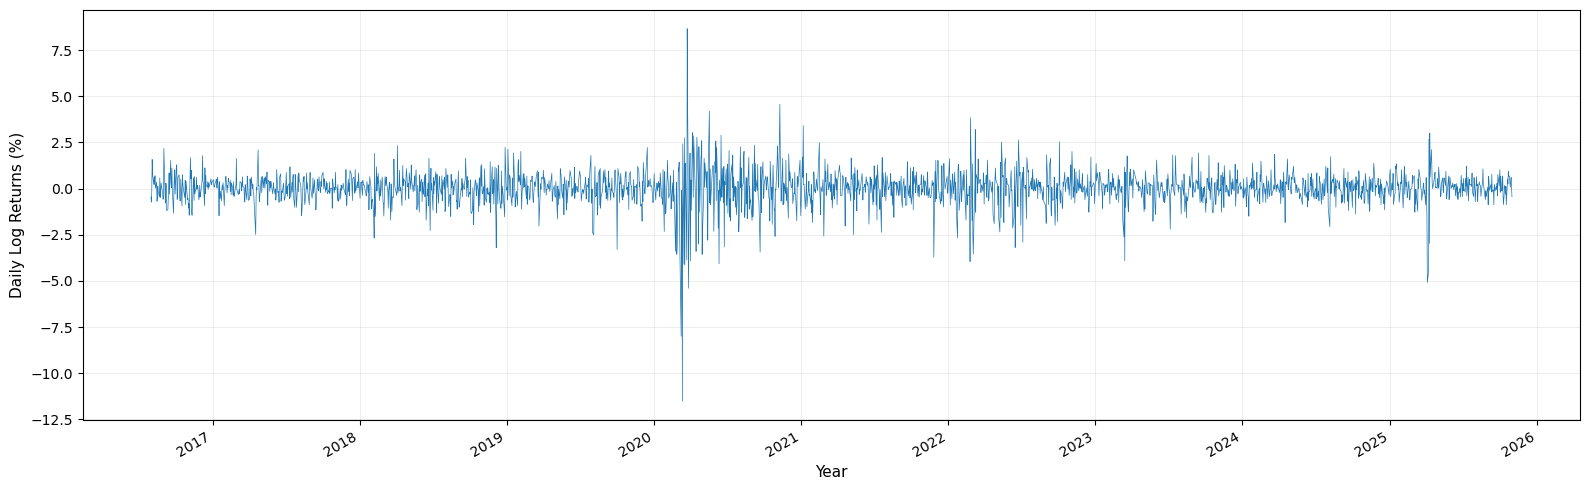

In [324]:
#Graph of returns
ax = common_df["returns"].plot(
    figsize=(16, 5),
    linewidth=0.5,           
    color='#1f77b4',
    ylabel='Daily Log Returns (%)'
)

ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Daily Log Returns (%)', fontsize=11)
ax.tick_params(axis='both', labelsize=10)

ax.grid(True, alpha=0.3, linewidth=0.5)   

plt.tight_layout()
plt.savefig("ftse100_returns.png", dpi=300, bbox_inches='tight')
plt.show()

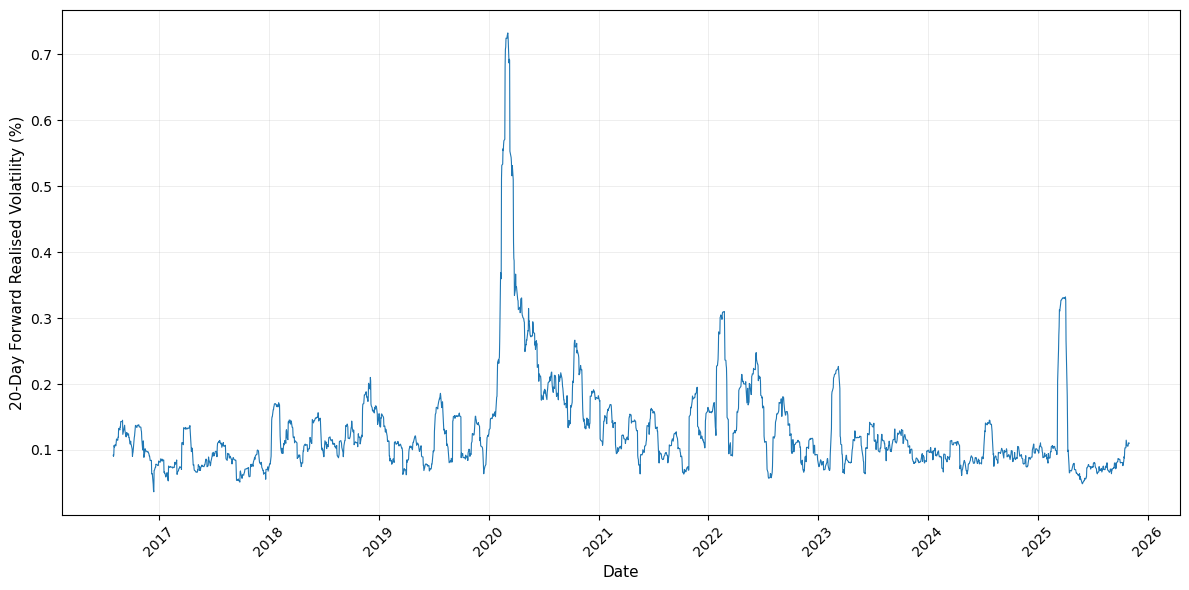

In [325]:
#Graph of target
plt.figure(figsize=(12, 6))
plt.plot(common_df["target"], linewidth=0.8, color='#1f77b4')

plt.ylabel("20-Day Forward Realised Volatility (%)", fontsize=11)
plt.xlabel("Date", fontsize=11)
plt.xticks(rotation=45, fontsize=10)
plt.yticks(fontsize=10)
plt.grid(True, alpha=0.3, linewidth=0.5)

plt.tight_layout()
plt.savefig("ftse100_realised_vol.pdf", bbox_inches='tight')
plt.show()

In [326]:
#-------------------------------------------------------------------------------------------------------------------
# GARCH
#-------------------------------------------------------------------------------------------------------------------

In [327]:
#Split data into train and test
train = common_df["returns"].loc[:'2022-12-31'].dropna()
test = common_df["returns"].loc['2023-01-01':].dropna()

In [328]:
#Fit GARCH model- fit once for in sample

model_in = arch_model(
    train,
    mean="Constant",
    vol="GARCH",
    p=1,
    q=1
)

results_in = model_in.fit(disp="off")

garch_in_sample = (
    results_in.conditional_volatility 
    / 100 
    * np.sqrt(252)
)

garch_in_sample.name = "Forecast"

In [329]:
garch_in_sample = pd.Series(
    garch_in_sample,
    index=train.index,
    name="GARCH"
)

In [330]:
#Fit GARCH model- using expanding window estimation for out of sample

predictions = []

history = train.copy()

for i in range(len(test)):

    model = arch_model(
        history,
        mean = "Constant",
        vol = "GARCH",
        p=1,
        q=1
    )

    results = model.fit(disp="off")

    forecast = results.forecast(horizon=20)

    forecast_variance = forecast.variance.iloc[-1].values

    GARCH_forecast = (
        np.sqrt(forecast_variance.mean()) 
        * np.sqrt(252) 
        / 100
    )

    predictions.append(GARCH_forecast)

    history = pd.concat([history, test.iloc[[i]]])

In [331]:
print(results.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                returns   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -2763.96
Distribution:                  Normal   AIC:                           5535.91
Method:            Maximum Likelihood   BIC:                           5558.94
                                        No. Observations:                 2338
Date:                Mon, Sep 07 2026   Df Residuals:                     2337
Time:                        22:31:10   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu             0.0403  1.487e-02      2.712  6.696e-03 [1.

In [332]:
#Estimate parameters
param = model.fit(disp="off")

In [335]:
#Turn data into series 
GARCH_predictions = pd.Series(
    predictions,
    index=test.index,
    name="GARCH_forecast"
)

In [336]:
#-------------------------------------------------------------------------------------------------------------------
# XGBoost
#-------------------------------------------------------------------------------------------------------------------

In [337]:
#Create results storage
xgb_in_predictions = {}
xgb_predictions = {}
results = []

In [338]:
for model_name, features in features_set.items():

    #Remove missing values for this particular model
    df = common_df.copy()

    #Create X and y
    X = df[features]
    y = df["target"]

    #Split into training and testing
    X_train = X.loc[:'2022-12-31']
    X_test = X.loc['2023-01-01':]

    y_train = y.loc[:'2022-12-31']
    y_test = y.loc['2023-01-01':]

    #Create XGBoost model
    model = xgb.XGBRegressor(
        objective="reg:squarederror",
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        random_state=42
    )

    #Fit model
    model.fit(X_train, y_train)

    #In-sample prediction
    train_predictions = model.predict(X_train)

    #Save-in-sample prediction
    xgb_in_predictions[model_name] = pd.Series(
    train_predictions,
    index=X_train.index,
    name=model_name
    )

    #Out-of-sample prediction
    test_predictions = model.predict(X_test)

    #Save out-of-sample predictions
    xgb_predictions[model_name] = pd.Series(
        test_predictions,
        index=X_test.index,
        name=model_name
    )

    #Calculate MAE
    in_mae = mean_absolute_error(
        y_train,
        train_predictions
    )

    out_mae = mean_absolute_error(
        y_test,
        test_predictions
    )

    #Calculate RMSE
    in_rmse = np.sqrt(
        mean_squared_error(
            y_train,
            train_predictions
        )
    )

    out_rmse = np.sqrt(
        mean_squared_error(
            y_test,
            test_predictions
        )
    )

    #Store results
    results.append({
        "Model": model_name,
        "In_sample_MAE": in_mae,
        "Out_of_sample_MAE": out_mae,
        "In_sample_RMSE": in_rmse,
        "Out_of_sample_RMSE": out_rmse
    })

In [339]:
#-------------------------------------------------------------------------------------------------------------------
# Model performance comparison
#-------------------------------------------------------------------------------------------------------------------

In [340]:
#Compute in sample results comparison table
in_sample_results = []

for model_name, xgb_pred in xgb_in_predictions.items():

    comparison_in = pd.concat(
        [
            Target_train.rename("Actual"),
            garch_in_sample.rename("GARCH"),
            xgb_pred.rename("XGBoost")
        ],
        axis=1
    )

    #Only keep dates where all three exist
    comparison_in = comparison_in.dropna()

    print(
        model_name,
        "observations:",
        len(comparison_in)
    )

    #GARCH MAE
    garch_mae = mean_absolute_error(
        comparison_in["Actual"],
        comparison_in["GARCH"]
    )

    #GARCH RMSE
    garch_rmse = np.sqrt(
        mean_squared_error(
            comparison_in["Actual"],
            comparison_in["GARCH"]
        )
    )

    #XGBoost MAE
    xgb_mae = mean_absolute_error(
        comparison_in["Actual"],
        comparison_in["XGBoost"]
    )

    #XGBoost RMSE
    xgb_rmse = np.sqrt(
        mean_squared_error(
            comparison_in["Actual"],
            comparison_in["XGBoost"]
        )
    )

    in_sample_results.append({
        "XGBoost Model": model_name,
        "Observations": len(comparison_in),
        "GARCH MAE": garch_mae,
        "XGBoost MAE": xgb_mae,
        "GARCH RMSE": garch_rmse,
        "XGBoost RMSE": xgb_rmse
    })

in_sample_results = pd.DataFrame(in_sample_results)

print(in_sample_results)

XGBoost 1 - Returns observations: 1622
XGBoost 2 - Returns + Volatility observations: 1622
XGBoost 3 - + Volume observations: 1622
XGBoost 4 - + Macro observations: 1622
XGBoost 5 - + Social Media observations: 1622
                      XGBoost Model  Observations  GARCH MAE  XGBoost MAE  \
0               XGBoost 1 - Returns          1622   0.044458     0.030961   
1  XGBoost 2 - Returns + Volatility          1622   0.044458     0.023786   
2              XGBoost 3 - + Volume          1622   0.044458     0.022625   
3               XGBoost 4 - + Macro          1622   0.044458     0.011323   
4        XGBoost 5 - + Social Media          1622   0.044458     0.008988   

   GARCH RMSE  XGBoost RMSE  
0    0.070746      0.042104  
1    0.070746      0.033592  
2    0.070746      0.032405  
3    0.070746      0.014836  
4    0.070746      0.011891  


In [341]:
#Compute out of sample results comparison table
comparison_results = []

for model_name, xgb_pred in xgb_predictions.items():

    #Find dates available for all three
    common_dates = (
        Target_test.index
        .intersection(GARCH_predictions.index)
        .intersection(xgb_pred.index)
    )
    
    comparison = pd.concat(
        [
            Target_test.rename("Actual"),
            GARCH_predictions.rename("GARCH"),
            xgb_pred.rename("XGBoost")
        ],
        axis=1
    ).dropna()

    #GARCH metrics
    garch_mae = mean_absolute_error(
        comparison["Actual"],
        comparison["GARCH"]
    )

    garch_rmse = np.sqrt(
        mean_squared_error(
            comparison["Actual"],
            comparison["GARCH"]
        )
    )

    #XGBoost metrics
    xgb_mae = mean_absolute_error(
        comparison["Actual"],
        comparison["XGBoost"]
    )

    xgb_rmse = np.sqrt(
        mean_squared_error(
            comparison["Actual"],
            comparison["XGBoost"]
        )
    )

    comparison_results.append({
        "XGBoost Model": model_name,
        "Observations": len(comparison),

        "GARCH MAE": garch_mae,
        "XGBoost MAE": xgb_mae,

        "GARCH RMSE": garch_rmse,
        "XGBoost RMSE": xgb_rmse
    })

comparison_results = pd.DataFrame(comparison_results)

print(comparison_results)

                      XGBoost Model  Observations  GARCH MAE  XGBoost MAE  \
0               XGBoost 1 - Returns           717   0.044941     0.041776   
1  XGBoost 2 - Returns + Volatility           717   0.044941     0.038874   
2              XGBoost 3 - + Volume           717   0.044941     0.047117   
3               XGBoost 4 - + Macro           717   0.044941     0.046300   
4        XGBoost 5 - + Social Media           717   0.044941     0.048884   

   GARCH RMSE  XGBoost RMSE  
0    0.058393      0.061963  
1    0.058393      0.060224  
2    0.058393      0.064785  
3    0.058393      0.064741  
4    0.058393      0.062439  


In [342]:
#-------------------------------------------------------------------------------------------------------------------
# DM Test
#-------------------------------------------------------------------------------------------------------------------

In [343]:
def dm_test_hac(actual, forecast_1, forecast_2, loss="mae", maxlags=19):

    actual = np.asarray(actual)
    forecast_1 = np.asarray(forecast_1)
    forecast_2 = np.asarray(forecast_2)

    #Forecast errors
    error_1 = actual - forecast_1
    error_2 = actual - forecast_2

    #Loss function
    if loss == "mae":
        loss_1 = np.abs(error_1)
        loss_2 = np.abs(error_2)

    elif loss == "mse":
        loss_1 = error_1 ** 2
        loss_2 = error_2 ** 2

    else:
        raise ValueError("loss must be 'mae' or 'mse'")

    #Loss differential
    d = loss_1 - loss_2

    #Remove missing observations
    d = d[~np.isnan(d)]

    T = len(d)

    #Mean loss differential
    d_bar = np.mean(d)

    #Newey-West/HAC variance
    d_centered = d - d_bar

    gamma_0 = np.mean(d_centered ** 2)

    gamma = []

    for lag in range(1, maxlags + 1):
        covariance = np.mean(
            d_centered[lag:] * d_centered[:-lag]
        )
        gamma.append(covariance)

    #Bartlett weights
    hac_variance = gamma_0

    for lag, covariance in enumerate(gamma, start=1):
        weight = 1 - lag / (maxlags + 1)
        hac_variance += 2 * weight * covariance

    hac_variance = hac_variance / T

    #DM statistic
    dm_stat = d_bar / np.sqrt(hac_variance)

    #Two-sided p-value
    p_value = 2 * (1 - stats.norm.cdf(abs(dm_stat)))

    return {
        "DM Statistic": dm_stat,
        "p-value": p_value
    }

In [344]:
dm_results = []

for model_name, xgb_pred in xgb_predictions.items():

    dm_data = pd.concat(
        [
            y_test.rename("actual"),
            xgb_pred.rename("xgb"),
            GARCH_dm.rename("garch")
        ],
        axis=1
    ).dropna()

    #DM test using absolute errors (MAE)
    dm_mae = dm_test_hac(
        actual=dm_data["actual"],
        forecast_1=dm_data["xgb"],
        forecast_2=dm_data["garch"],
        loss="mae",
        maxlags=19
    )

    #DM test using squared errors (RMSE/MSE)
    dm_mse = dm_test_hac(
        actual=dm_data["actual"],
        forecast_1=dm_data["xgb"],
        forecast_2=dm_data["garch"],
        loss="mse",
        maxlags=19
    )

    dm_results.append({
        "Model": model_name,
        "Observations": len(dm_data),
        "MAE DM Statistic": dm_mae["DM Statistic"],
        "MAE p-value": dm_mae["p-value"],
        "MSE DM Statistic": dm_mse["DM Statistic"],
        "MSE p-value": dm_mse["p-value"]
    })

dm_results = pd.DataFrame(dm_results)

print(dm_results)

                              Model  Observations  MAE DM Statistic  \
0               XGBoost 1 - Returns           717         -2.767218   
1  XGBoost 2 - Returns + Volatility           717         -2.288195   
2              XGBoost 3 - + Volume           717          0.910540   
3               XGBoost 4 - + Macro           717          0.342769   
4        XGBoost 5 - + Social Media           717          1.120845   

   MAE p-value  MSE DM Statistic  MSE p-value  
0     0.005654          0.980813     0.326685  
1     0.022126          0.404783     0.685637  
2     0.362538          1.999162     0.045591  
3     0.731772          1.003231     0.315749  
4     0.262354          0.949289     0.342474  


In [225]:
#Positive stat GARCH performs better (GARCH has lower forecast loss)
#Negative stat XGBoost performs better
#Take p-value at 5% level
#p<0.05 statistically significant difference

In [ ]:
#-------------------------------------------------------------------------------------------------------------------
# Model forecast vs target graph
#-------------------------------------------------------------------------------------------------------------------

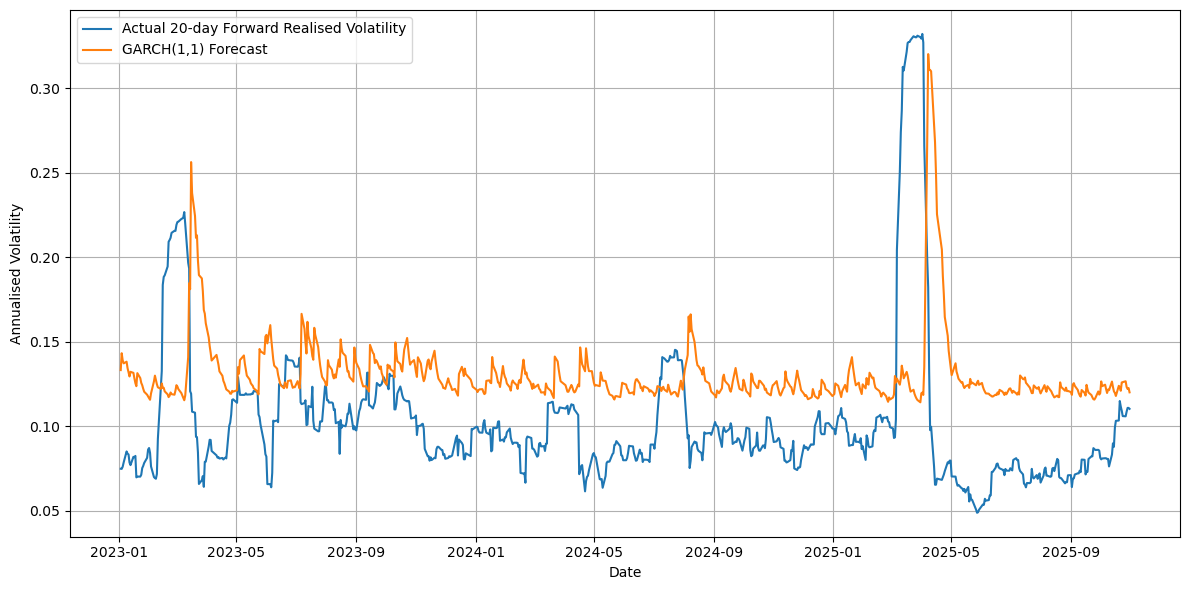

In [283]:
garch_plot = pd.concat(
    [
        y_test.rename("Actual"),
        GARCH_predictions.rename("GARCH")
    ],
    axis=1
).dropna()

plt.figure(figsize=(12, 6))

plt.plot(
    garch_plot.index,
    garch_plot["Actual"],
    label="Actual 20-day Forward Realised Volatility"
)

plt.plot(
    garch_plot.index,
    garch_plot["GARCH"],
    label="GARCH(1,1) Forecast"
)

plt.xlabel("Date")
plt.ylabel("Annualised Volatility")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

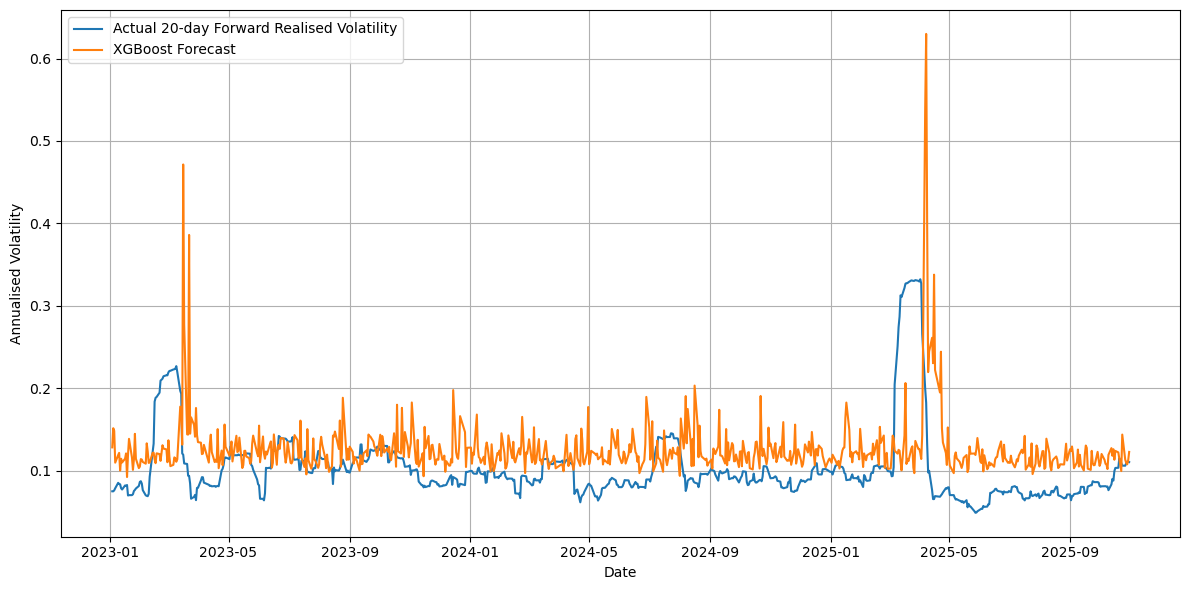

In [284]:
model_name = "XGBoost 1 - Returns"

xgb_plot = pd.concat(
    [
        y_test.rename("Actual"),
        xgb_predictions[model_name].rename("XGBoost")
    ],
    axis=1
).dropna()

plt.figure(figsize=(12, 6))

plt.plot(
    xgb_plot.index,
    xgb_plot["Actual"],
    label="Actual 20-day Forward Realised Volatility"
)

plt.plot(
    xgb_plot.index,
    xgb_plot["XGBoost"],
    label="XGBoost Forecast"
)

plt.xlabel("Date")
plt.ylabel("Annualised Volatility")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

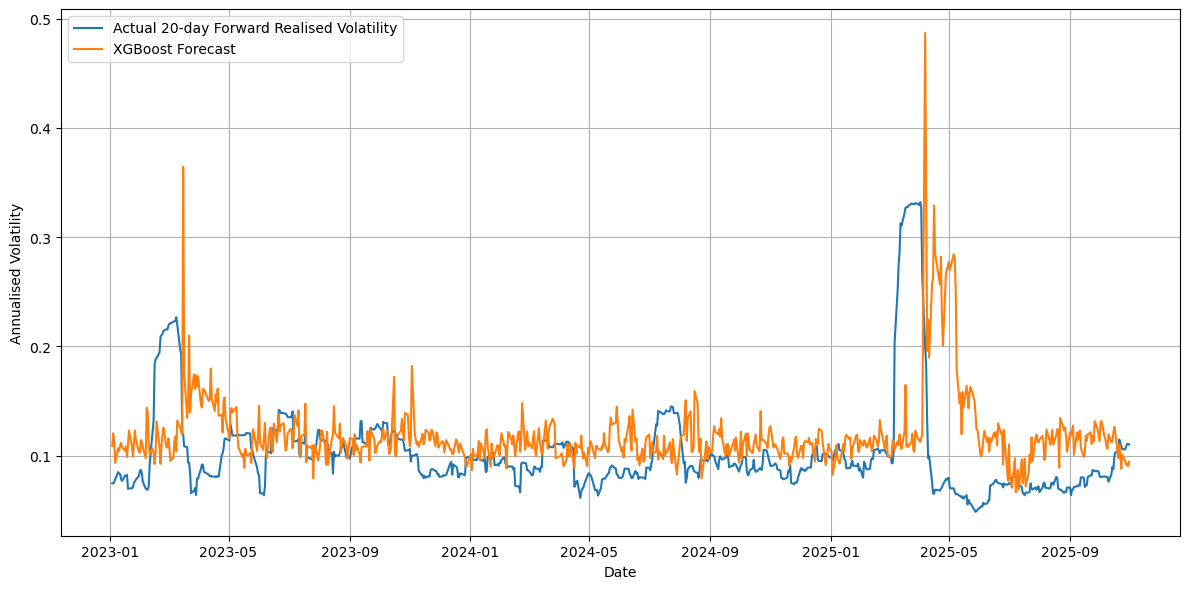

In [285]:
model_name = "XGBoost 2 - Returns + Volatility"

xgb_plot = pd.concat(
    [
        y_test.rename("Actual"),
        xgb_predictions[model_name].rename("XGBoost")
    ],
    axis=1
).dropna()

plt.figure(figsize=(12, 6))

plt.plot(
    xgb_plot.index,
    xgb_plot["Actual"],
    label="Actual 20-day Forward Realised Volatility"
)

plt.plot(
    xgb_plot.index,
    xgb_plot["XGBoost"],
    label="XGBoost Forecast"
)

plt.xlabel("Date")
plt.ylabel("Annualised Volatility")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

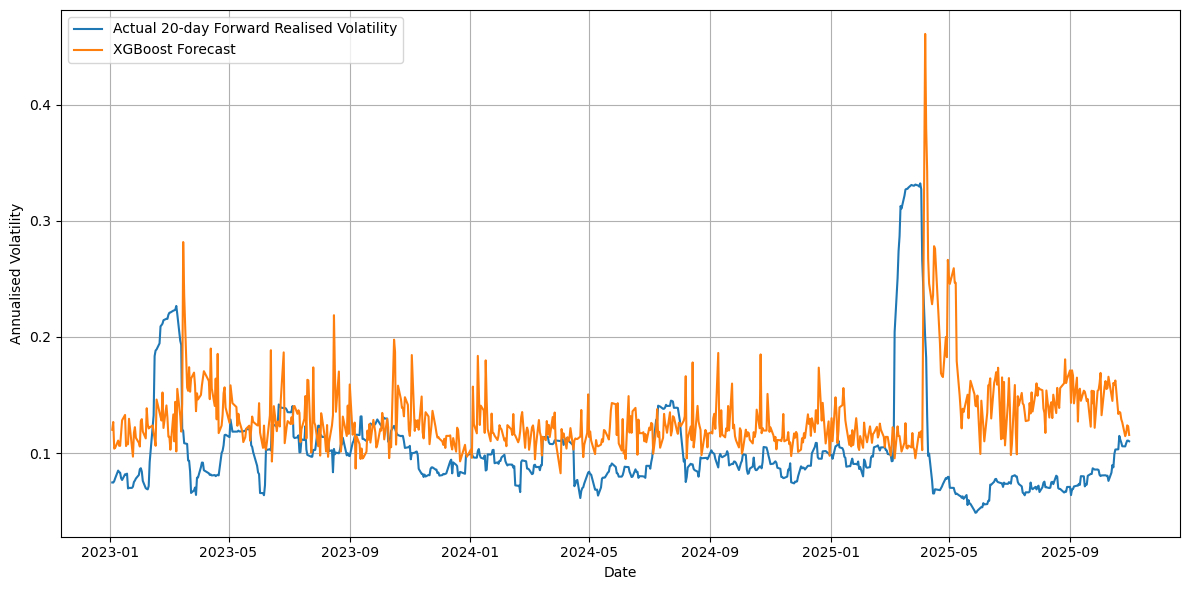

In [286]:
model_name = "XGBoost 3 - + Volume"

xgb_plot = pd.concat(
    [
        y_test.rename("Actual"),
        xgb_predictions[model_name].rename("XGBoost")
    ],
    axis=1
).dropna()

plt.figure(figsize=(12, 6))

plt.plot(
    xgb_plot.index,
    xgb_plot["Actual"],
    label="Actual 20-day Forward Realised Volatility"
)

plt.plot(
    xgb_plot.index,
    xgb_plot["XGBoost"],
    label="XGBoost Forecast"
)

plt.xlabel("Date")
plt.ylabel("Annualised Volatility")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

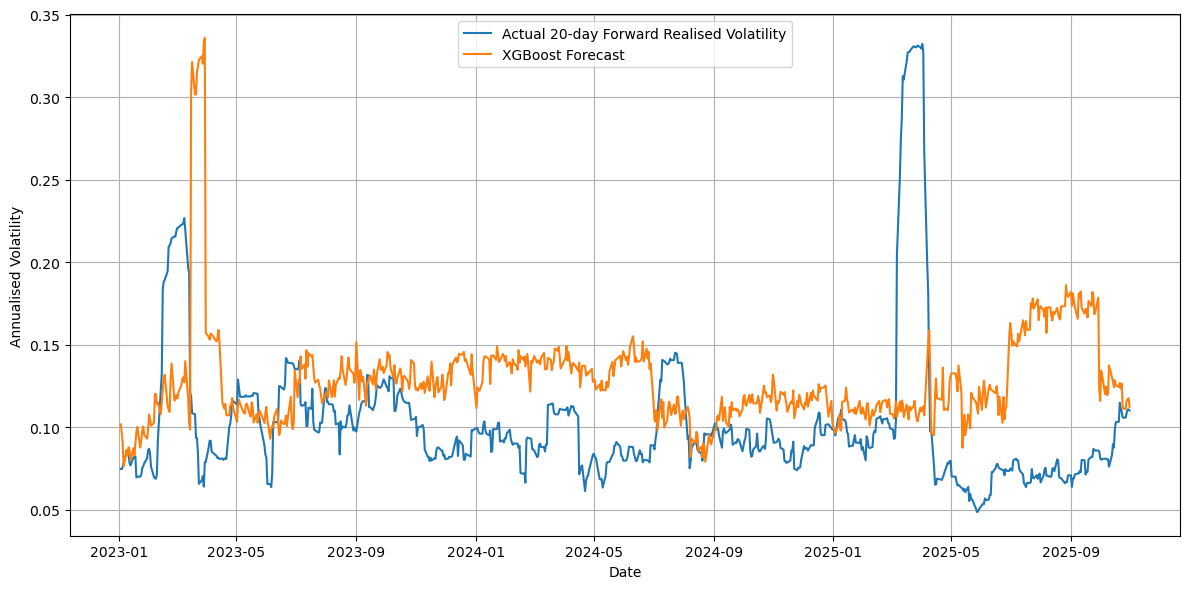

In [287]:
model_name = "XGBoost 4 - + Macro"

xgb_plot = pd.concat(
    [
        y_test.rename("Actual"),
        xgb_predictions[model_name].rename("XGBoost")
    ],
    axis=1
).dropna()

plt.figure(figsize=(12, 6))

plt.plot(
    xgb_plot.index,
    xgb_plot["Actual"],
    label="Actual 20-day Forward Realised Volatility"
)

plt.plot(
    xgb_plot.index,
    xgb_plot["XGBoost"],
    label="XGBoost Forecast"
)

plt.xlabel("Date")
plt.ylabel("Annualised Volatility")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

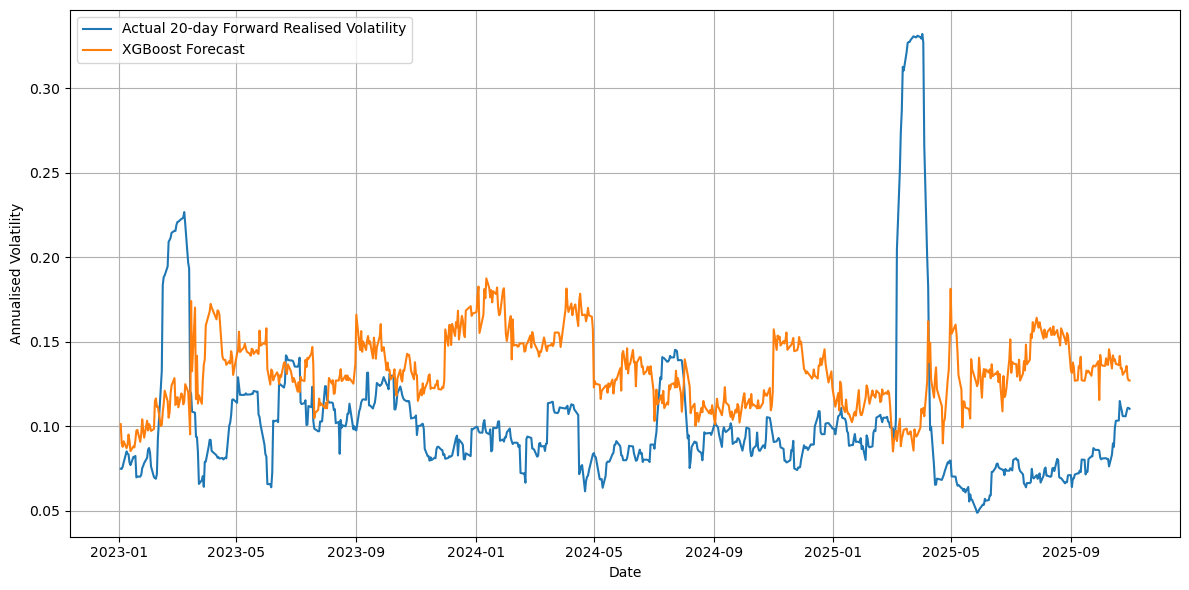

In [289]:
model_name = "XGBoost 5 - + Social Media"

xgb_plot = pd.concat(
    [
        y_test.rename("Actual"),
        xgb_predictions[model_name].rename("XGBoost")
    ],
    axis=1
).dropna()

plt.figure(figsize=(12, 6))

plt.plot(
    xgb_plot.index,
    xgb_plot["Actual"],
    label="Actual 20-day Forward Realised Volatility"
)

plt.plot(
    xgb_plot.index,
    xgb_plot["XGBoost"],
    label="XGBoost Forecast"
)

plt.xlabel("Date")
plt.ylabel("Annualised Volatility")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()